# 01 Data Audit

**Goal of this notebook:** before any analysis, understand exactly what data we have, what we removed, and where the gaps are.

Run `python -m src.download_data` and `python -m src.clean_data` from the project root first.

In [10]:
# --- Setup ---
import sys
import json
from pathlib import Path

# Find the project root (the folder containing requirements.txt),
# so this notebook works no matter where Jupyter was started.
ROOT = Path.cwd()
while not (ROOT / "requirements.txt").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import DATA_RAW, DATA_PROCESSED, MANIFEST, FIGURES, TABLES, START_YEAR, END_YEAR

pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.spines.top": False, "axes.spines.right": False})

panel = pd.read_parquet(DATA_PROCESSED / "country_panel.parquet")
core = pd.read_parquet(DATA_PROCESSED / "core_panel.parquet")
coverage = pd.read_csv(TABLES / f"coverage_{START_YEAR}_{END_YEAR}.csv", index_col="country")
manifest = json.loads(MANIFEST.read_text())

print("Data downloaded at:", manifest["downloaded_at_utc"])

Data downloaded at: 2026-09-24T17:21:27+00:00


## Q1. What does the cleaned panel contain?

In [11]:
print(f"Full panel: {panel.shape[0]:,} rows, {panel['country'].nunique()} countries, "
      f"{panel['year'].min()} to {panel['year'].max()}")
print(f"Core panel: {core.shape[0]:,} rows, {core['country'].nunique()} countries, "
      f"{core['year'].min()} to {core['year'].max()}")
panel.info()

Full panel: 42,480 rows, 218 countries, 1750 to 2024
Core panel: 5,049 rows, 153 countries, 1990 to 2022
<class 'pandas.DataFrame'>
RangeIndex: 42480 entries, 0 to 42479
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        42480 non-null  str    
 1   iso_code                       42480 non-null  str    
 2   year                           42480 non-null  int64  
 3   population                     38332 non-null  float64
 4   gdp                            15230 non-null  float64
 5   co2                            23408 non-null  float64
 6   co2_per_capita                 22945 non-null  float64
 7   co2_per_gdp                    14672 non-null  float64
 8   co2_per_unit_energy            9804 non-null   float64
 9   consumption_co2                4064 non-null   float64
 10  trade_co2                      4063 non-null   float64
 11  trade_co2_sh

## Q2. What did we remove, and was that right?

Regional aggregates share the `country` column with real countries. Keeping them would double count. They have no ISO code, so that is how the cleaning script drops them. Check the list for anything that *is* a real country.

In [12]:
raw = pd.read_csv(DATA_RAW / "owid-co2-data.csv", usecols=["country", "iso_code"])
dropped = sorted(raw.loc[raw["iso_code"].isna(), "country"].unique())
print(f"{len(dropped)} entries dropped:\n")
for name in dropped:
    print(" -", name)

36 entries dropped:

 - Africa
 - Africa (GCP)
 - Asia
 - Asia (GCP)
 - Asia (excl. China and India)
 - Central America (GCP)
 - Europe
 - Europe (GCP)
 - Europe (excl. EU-27)
 - Europe (excl. EU-28)
 - European Union (27)
 - European Union (28)
 - High-income countries
 - International aviation
 - International shipping
 - Kosovo
 - Kuwaiti Oil Fires
 - Kuwaiti Oil Fires (GCP)
 - Least developed countries (Jones et al.)
 - Low-income countries
 - Lower-middle-income countries
 - Middle East (GCP)
 - Non-OECD (GCP)
 - North America
 - North America (GCP)
 - North America (excl. USA)
 - OECD (GCP)
 - OECD (Jones et al.)
 - Oceania
 - Oceania (GCP)
 - Ryukyu Islands
 - Ryukyu Islands (GCP)
 - South America
 - South America (GCP)
 - Upper-middle-income countries
 - World


> **Caveat to note:** Kosovo has no ISO code in this file, so it is dropped along with the aggregates. Its emissions are small, so the effect is negligible.

## Q3. Which countries have complete data for the analysis window?

In [13]:
complete = coverage[coverage["complete_core"]]
incomplete = coverage[~coverage["complete_core"]]
print(f"Complete core data {START_YEAR}-{END_YEAR}: {len(complete)} countries")
print(f"Incomplete: {len(incomplete)} countries")
print(f"Of the complete ones, with full consumption-based CO2 too: "
      f"{(complete['consumption_co2'] == 1).sum()}")

# Which large emitters (if any) are missing from the core panel?
latest = panel[panel["year"] == END_YEAR].set_index("country")["co2"]
missing_big = latest.reindex(incomplete.index).sort_values(ascending=False).head(10)
print("\nLargest emitters NOT in the core panel (Mt CO2, latest year):")
print(missing_big.round(1))

Complete core data 1990-2022: 153 countries
Incomplete: 65 countries
Of the complete ones, with full consumption-based CO2 too: 111

Largest emitters NOT in the core panel (Mt CO2, latest year):
country
United Arab Emirates      207.1
Serbia                     44.5
Bosnia and Herzegovina     20.7
Sudan                      17.5
Brunei                     12.2
Georgia                    12.0
Kyrgyzstan                 11.5
Tajikistan                 10.5
Papua New Guinea            8.4
Armenia                     7.7
Name: co2, dtype: float64


## Q4. Who are the biggest emitters, and how concentrated are emissions?

In [14]:
top = (panel[panel["year"] == END_YEAR]
       .set_index("country")["co2"]
       .sort_values(ascending=False))
share = (top / top.sum() * 100).round(1)
summary = pd.DataFrame({"co2_mt": top.round(1), "share_pct": share,
                        "cumulative_pct": share.cumsum().round(1)})
summary.head(15)

,co2_mt,share_pct,cumulative_pct
country,,,
China,11711.8,32.0,32.0
United States,5055.4,13.8,45.8
India,2831.1,7.7,53.5
Russia,1675.5,4.6,58.1
Japan,1029.6,2.8,60.9
Iran,767.2,2.1,63.0
Indonesia,758.0,2.1,65.1
Germany,667.8,1.8,66.9
Saudi Arabia,667.0,1.8,68.7


## Q5. Sanity check: do the countries add up to the World total?

If the sum of countries is far from the "World" row, something went wrong in cleaning (or the gap is explained by things like international shipping and aviation, which belong to no country).

In [15]:
world = pd.read_csv(DATA_RAW / "owid-co2-data.csv", usecols=["country", "year", "co2"])
world = world[world["country"] == "World"].set_index("year")["co2"]
countries_sum = panel.groupby("year")["co2"].sum()

check = pd.DataFrame({"world": world, "sum_of_countries": countries_sum}).loc[1990:END_YEAR]
check["gap_pct"] = ((check["world"] - check["sum_of_countries"]) / check["world"] * 100).round(2)
check.tail(8)

,world,sum_of_countries,gap_pct
year,,,
2015,35403.527,34242.623,3.28
2016,35392.832,34214.960,3.33
2017,35974.609,34765.472,3.36
2018,36734.004,35489.581,3.39
2019,37086.566,35838.605,3.36
2020,35158.230,34310.228,2.41
2021,36866.863,35978.968,2.41
2022,37527.773,36553.536,2.60


## Q6. First look at the offshoring question: UK production vs consumption emissions

Production-based = emitted inside the UK. Consumption-based = emissions from everything the UK consumes, including imported goods. A widening gap means some of the UK's footprint happens abroad.

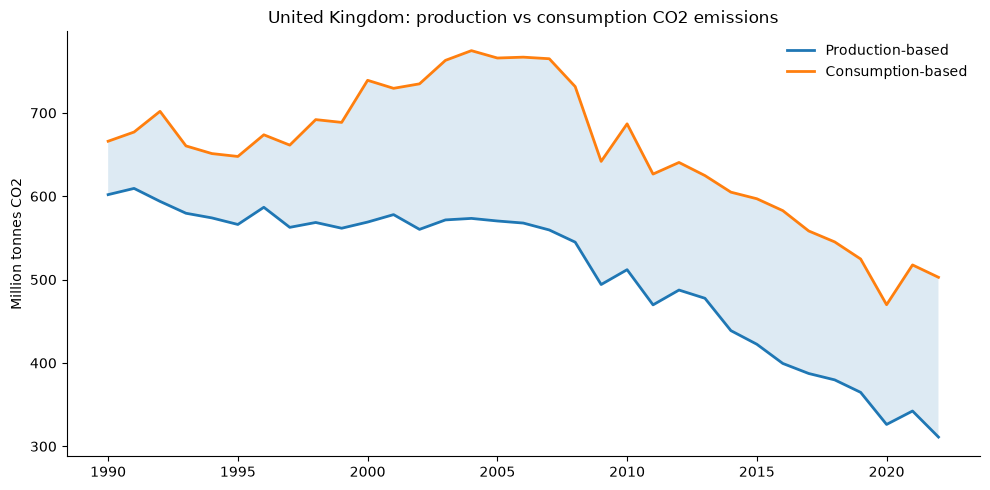

In [16]:
uk = panel[(panel["country"] == "United Kingdom") & panel["year"].between(START_YEAR, END_YEAR)]

fig, ax = plt.subplots()
ax.plot(uk["year"], uk["co2"], label="Production-based", linewidth=2)
ax.plot(uk["year"], uk["consumption_co2"], label="Consumption-based", linewidth=2)
ax.fill_between(uk["year"], uk["co2"], uk["consumption_co2"], alpha=0.15)
ax.set_title("United Kingdom: production vs consumption CO2 emissions")
ax.set_ylabel("Million tonnes CO2")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "01_uk_production_vs_consumption.png", dpi=150)
plt.show()

## Q7. First look at the energy mix: how has the UK's changed?

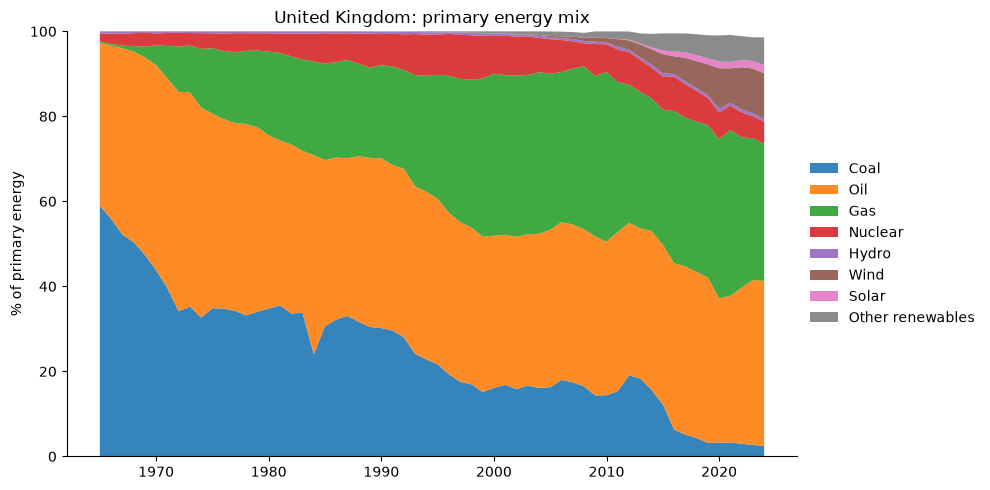

In [17]:
sources = {
    "coal_share_energy": "Coal", "oil_share_energy": "Oil", "gas_share_energy": "Gas",
    "nuclear_share_energy": "Nuclear", "hydro_share_energy": "Hydro",
    "wind_share_energy": "Wind", "solar_share_energy": "Solar",
    "other_renewables_share_energy": "Other renewables",
}
uk_mix = (panel[panel["country"] == "United Kingdom"]
          .set_index("year")[list(sources)]
          .rename(columns=sources)
          .dropna(how="all")
          .fillna(0))

fig, ax = plt.subplots()
ax.stackplot(uk_mix.index, uk_mix.T.values, labels=uk_mix.columns, alpha=0.9)
ax.set_title("United Kingdom: primary energy mix")
ax.set_ylabel("% of primary energy")
ax.set_ylim(0, 100)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "01_uk_energy_mix.png", dpi=150, bbox_inches="tight")
plt.show()

## Q8. Preview of decoupling: GDP growth vs CO2 change, 1990 to 2022

Each dot is a country. Right of the vertical line = economy grew. Below the horizontal line = emissions fell. Countries in the **bottom right** have absolutely decoupled. This is a preview only; the proper classification comes in notebook 02.

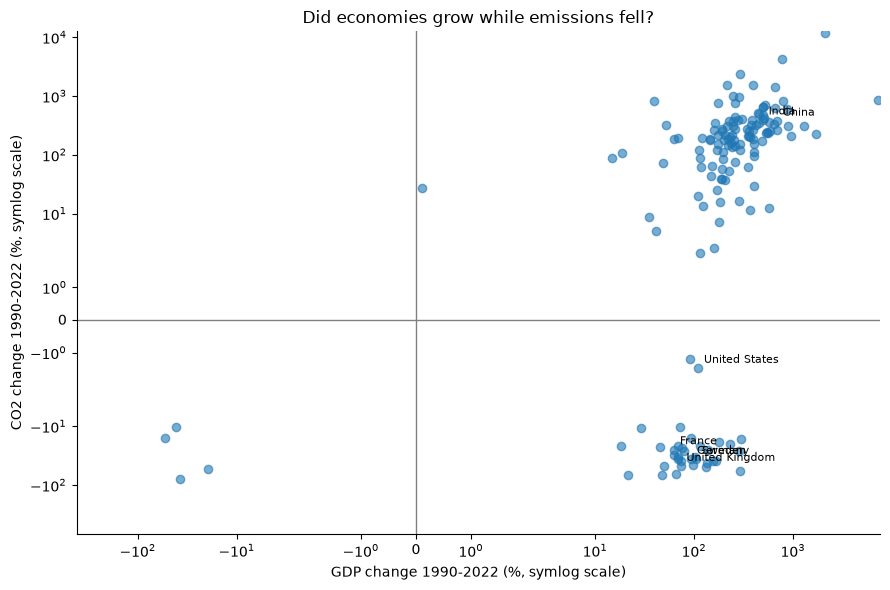

35 of 153 countries grew GDP while cutting CO2 over the period.


In [18]:
ends = core[core["year"].isin([START_YEAR, END_YEAR])].pivot(index="country", columns="year", values=["gdp", "co2"])
change = pd.DataFrame({
    "gdp_change_pct": (ends[("gdp", END_YEAR)] / ends[("gdp", START_YEAR)] - 1) * 100,
    "co2_change_pct": (ends[("co2", END_YEAR)] / ends[("co2", START_YEAR)] - 1) * 100,
})

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(change["gdp_change_pct"], change["co2_change_pct"], alpha=0.6)
ax.axhline(0, color="grey", linewidth=1)
ax.axvline(0, color="grey", linewidth=1)
for name in ["United Kingdom", "Germany", "United States", "China", "India", "France", "Sweden"]:
    if name in change.index:
        x, y = change.loc[name]
        ax.annotate(name, (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xscale("symlog")
ax.set_yscale("symlog")
ax.set_xlabel(f"GDP change {START_YEAR}-{END_YEAR} (%, symlog scale)")
ax.set_ylabel(f"CO2 change {START_YEAR}-{END_YEAR} (%, symlog scale)")
ax.set_title("Did economies grow while emissions fell?")
fig.tight_layout()
fig.savefig(FIGURES / "01_decoupling_preview.png", dpi=150)
plt.show()

decoupled = change[(change["gdp_change_pct"] > 0) & (change["co2_change_pct"] < 0)]
print(f"{len(decoupled)} of {len(change)} countries grew GDP while cutting CO2 over the period.")

## Audit notes

- **Core panel:** 153 of 218 countries have complete population, GDP, CO2 and energy data for 1990 to 2022. 111 of these also have consumption-based emissions, so the offshoring analysis will use that smaller group.

- **What was dropped:** 36 entries without an ISO code, almost all regional or income-group aggregates. The exception is Kosovo, a real country with no ISO code in the source. Its emissions are small, so excluding it has a negligible effect.

- **Missing emitters:** The UAE (207 Mt in 2022) is the largest emitter outside the core panel. Most other gaps are countries that were not independent in 1990 (Serbia, Georgia, Armenia), so they lack a full series. Results describe countries with continuous data, not every country.

- **Concentration:** China, the US and India alone produce over half of global emissions (53.5% in 2022). Any global story is largely driven by these three.

- **World total check:** Countries sum to 2.4 to 3.4% less than the World figure. The gap is mainly international shipping and aviation, which are not assigned to any country. Cleaning did not lose data.

- **UK production vs consumption:** Production emissions fell 48% (602 to 311 Mt) between 1990 and 2022, but consumption emissions fell only 25% (666 to 503 Mt). The gap peaked in 2007 and is still around 190 Mt, so part of the UK's footprint sits in imported goods. This needs testing properly in the offshoring section.

- **UK energy mix:** Coal fell from 30% of primary energy in 1990 to 3% in 2022, while low-carbon sources rose from 8% to 25%. Gas absorbed much of coal's share.

- **Decoupling preview:** 35 of 153 countries (23%) grew GDP while cutting CO2 over the period. This is a simple start-to-end comparison and will be formalised in notebook 02.